# Active Preference Learning via Polytope Volume Removal

Instead of heuristic sample filtering, we maintain the feasible set $\Omega_t$ as an **explicit polytope** $\{\omega : A\omega \leq b\}$.

Each pairwise response (left, right, indifferent, incomparable) adds **linear constraints** on $\omega$,
and we select queries to **maximize expected volume removal** (Sadigh et al. 2017).

### Constraint rules (from the frame model)

Given query gaps $\Delta_j$ and thresholds $\tau, \tau'$:

| Response | Constraints on $\omega$ |
|----------|------------------------|
| **Left** ($Y \succ Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) \geq 0$ |
| **Right** ($Y \prec Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) \leq 0$ |
| **Indifferent** ($Y \sim Y'$) | $\sum \omega_j |\Delta_j| \leq \tau - \eta$ |
| **Incomparable** ($Y \bowtie Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$, $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) < 0$, $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) > 0$ |

In [25]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.spatial.distance import pdist
from typing import List, Tuple, Optional, Set
import matplotlib.pyplot as plt
import seaborn as sns

from core import (
    Patient, PairwiseQuery, FEATURE_NAMES, FEATURE_RANGES,
    compute_frame_gaps, predict_response, compute_aggregate_scores,
    generate_random_patient,
)
# Algorithm parameters
TAU = 0.5  # Intensity threshold
TAU_PRIME = 0.5  # Resolvability threshold
LAMBDA_X = 1.0  # Query scaling factor (can be a function later)
sns.set_style('whitegrid')

print(f'Features: {FEATURE_NAMES}')
print(f'tau={TAU}, tau_prime={TAU_PRIME}, lambda_x={LAMBDA_X}')

Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
tau=0.5, tau_prime=0.5, lambda_x=1.0


## Polytope class

H-representation: $\Omega = \{\omega \in \mathbb{R}^d : A\omega \leq b\}$

With hit-and-run MCMC sampling and Chebyshev center computation.

In [26]:
class ConstraintPolytope:
    """Convex polytope in H-representation: {w : Aw <= b}.

    For the simplex, we store the equality sum(w)=1 separately and
    handle it via two inequality constraints (sum <= 1, -sum <= -1).
    The Chebyshev center LP uses a tolerance approach to find a
    strictly interior point of the inequality system.
    """

    def __init__(self, dim: int, geometry: str = 'simplex'):
        self.dim = dim
        self.geometry = geometry
        self._A_rows = []
        self._b_vals = []
        self._center_cache = None
        self._use_sphere_constraint = False

        if geometry == 'simplex':
            # w_j >= 0  =>  -w_j <= 0
            for j in range(dim):
                row = np.zeros(dim)
                row[j] = -1.0
                self._A_rows.append(row)
                self._b_vals.append(0.0)
            # sum w_j <= 1
            self._A_rows.append(np.ones(dim))
            self._b_vals.append(1.0)
            # sum w_j >= 1  =>  -sum w_j <= -1
            self._A_rows.append(-np.ones(dim))
            self._b_vals.append(-1.0)

        elif geometry == 'sphere':
            for j in range(dim):
                row_pos = np.zeros(dim)
                row_pos[j] = 1.0
                self._A_rows.append(row_pos)
                self._b_vals.append(1.0)
                row_neg = np.zeros(dim)
                row_neg[j] = -1.0
                self._A_rows.append(row_neg)
                self._b_vals.append(1.0)
            self._use_sphere_constraint = True
        else:
            raise ValueError(f'Unknown geometry: {geometry}')

    @property
    def A(self) -> np.ndarray:
        return np.array(self._A_rows)

    @property
    def b(self) -> np.ndarray:
        return np.array(self._b_vals)

    @property
    def n_constraints(self) -> int:
        return len(self._A_rows)

    def add_constraint(self, a: np.ndarray, b_val: float):
        """Add constraint a^T w <= b_val."""
        self._A_rows.append(a.copy())
        self._b_vals.append(b_val)
        self._center_cache = None

    def is_feasible(self, w: np.ndarray, tol: float = 1e-8) -> bool:
        """Check if w satisfies all constraints."""
        violations = self.A @ w - self.b
        if np.any(violations > tol):
            return False
        if self._use_sphere_constraint and np.linalg.norm(w) > 1.0 + tol:
            return False
        return True

    def chebyshev_center(self) -> Optional[np.ndarray]:
        """Find a strictly interior point of the polytope.

        For polytopes with equality constraints (like the simplex where
        sum=1), the classical Chebyshev center has radius 0. Instead we
        find the point that maximizes the minimum slack across all
        INEQUALITY constraints (excluding exact equalities).

        We detect near-equalities (pairs a^T x <= b and -a^T x <= -b)
        and handle them as equality constraints in the LP.
        """
        if self._center_cache is not None:
            return self._center_cache.copy()

        A = self.A
        b_vec = self.b
        m, d = A.shape

        # Detect equality pairs: rows i,j where A[i] ≈ -A[j] and b[i] ≈ -b[j]
        eq_rows = set()
        ineq_rows = list(range(m))
        for i in range(m):
            for j in range(i + 1, m):
                if (np.allclose(A[i], -A[j], atol=1e-10) and
                        abs(b_vec[i] + b_vec[j]) < 1e-10):
                    eq_rows.add(i)
                    eq_rows.add(j)

        ineq_rows = [i for i in range(m) if i not in eq_rows]
        eq_row_list = sorted(eq_rows)

        if len(ineq_rows) == 0:
            # Only equalities — just solve for feasibility
            # Use one row from each equality pair
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(A[i])
                    b_eq_vals.append(b_vec[i])
            A_eq = np.array(A_eq_rows)
            b_eq = np.array(b_eq_vals)
            # Least-norm solution
            x, _, _, _ = np.linalg.lstsq(A_eq, b_eq, rcond=None)
            if self.is_feasible(x):
                self._center_cache = x
                return x.copy()
            return None

        # Build LP: max r s.t. a_i^T x + r ||a_i|| <= b_i (for ineq rows)
        #           a_j^T x = b_j (for equality rows)
        A_ineq = A[ineq_rows]
        b_ineq = b_vec[ineq_rows]

        norms = np.linalg.norm(A_ineq, axis=1, keepdims=True)
        # Avoid division issues for zero-norm rows
        norms = np.maximum(norms, 1e-15)

        # Variables: [x_1, ..., x_d, r]
        c_obj = np.zeros(d + 1)
        c_obj[-1] = -1.0  # maximize r

        A_lp = np.hstack([A_ineq, norms])
        b_lp = b_ineq

        # Equality constraints from detected pairs (keep one per pair)
        A_eq_lp = None
        b_eq_lp = None
        if len(eq_row_list) > 0:
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(np.append(A[i], 0.0))  # r doesn't appear
                    b_eq_vals.append(b_vec[i])
            if A_eq_rows:
                A_eq_lp = np.array(A_eq_rows)
                b_eq_lp = np.array(b_eq_vals)

        bounds = [(None, None)] * d + [(0, None)]

        result = linprog(c_obj, A_ub=A_lp, b_ub=b_lp,
                         A_eq=A_eq_lp, b_eq=b_eq_lp,
                         bounds=bounds, method='highs')

        if result.success:
            center = result.x[:d]
            if self.is_feasible(center):
                self._center_cache = center
                return center.copy()

        # Fallback: try the centroid (1/d, ..., 1/d) for simplex
        if self.geometry == 'simplex':
            centroid = np.ones(d) / d
            if self.is_feasible(centroid):
                self._center_cache = centroid
                return centroid.copy()

        return None

    def _hit_and_run_step(self, x: np.ndarray) -> np.ndarray:
        """One hit-and-run step: random direction, find chord, sample uniformly."""
        A = self.A
        b_vec = self.b

        direction = np.random.randn(self.dim)
        direction /= np.linalg.norm(direction)

        # For simplex: project direction onto the sum=1 hyperplane
        if self.geometry == 'simplex':
            direction -= direction.mean()
            norm = np.linalg.norm(direction)
            if norm < 1e-15:
                return x
            direction /= norm

        # Find t range: A(x + t*d) <= b  =>  t*(Ad) <= b - Ax
        Ad = A @ direction
        residuals = b_vec - A @ x

        t_min = -np.inf
        t_max = np.inf

        for i in range(len(Ad)):
            if Ad[i] > 1e-12:
                t_max = min(t_max, residuals[i] / Ad[i])
            elif Ad[i] < -1e-12:
                t_min = max(t_min, residuals[i] / Ad[i])

        if t_min >= t_max - 1e-15:
            return x

        # For sphere constraint, also clip t range
        if self._use_sphere_constraint:
            a_coef = np.dot(direction, direction)
            b_coef = 2 * np.dot(x, direction)
            c_coef = np.dot(x, x) - 1.0
            disc = b_coef**2 - 4 * a_coef * c_coef
            if disc > 0:
                sqrt_disc = np.sqrt(disc)
                t_lo = (-b_coef - sqrt_disc) / (2 * a_coef)
                t_hi = (-b_coef + sqrt_disc) / (2 * a_coef)
                t_min = max(t_min, t_lo)
                t_max = min(t_max, t_hi)
            else:
                return x

        if t_min >= t_max - 1e-15:
            return x

        t = np.random.uniform(t_min, t_max)
        return x + t * direction

    def sample(self, n_samples: int, burn_in: int = 500, thin: int = 10) -> np.ndarray:
        """Sample from the polytope using hit-and-run MCMC."""
        center = self.chebyshev_center()
        if center is None:
            raise ValueError('Polytope appears empty (no Chebyshev center found)')

        x = center.copy()
        samples = []

        total_steps = burn_in + n_samples * thin
        for step in range(total_steps):
            x = self._hit_and_run_step(x)
            if step >= burn_in and (step - burn_in) % thin == 0:
                samples.append(x.copy())

        return np.array(samples)


# Quick test
poly = ConstraintPolytope(5, geometry='simplex')
center = poly.chebyshev_center()
print(f'Simplex Chebyshev center: {center}')
print(f'Sum = {center.sum():.4f}, all >= 0: {np.all(center >= -1e-10)}')
print(f'Initial constraints: {poly.n_constraints}')

samples = poly.sample(500, burn_in=200, thin=5)
print(f'\nSampled {len(samples)} points from simplex')
print(f'  Sum range: [{samples.sum(axis=1).min():.6f}, {samples.sum(axis=1).max():.6f}]')
print(f'  Min weight: {samples.min():.4f}')
print(f'  Mean: {samples.mean(axis=0)}')

Simplex Chebyshev center: [0.2 0.2 0.2 0.2 0.2]
Sum = 1.0000, all >= 0: True
Initial constraints: 7

Sampled 500 points from simplex
  Sum range: [1.000000, 1.000000]
  Min weight: 0.0002
  Mean: [0.2008488  0.19893337 0.18781319 0.19569704 0.2167076 ]


In [27]:
# Also test sphere geometry
poly_sphere = ConstraintPolytope(5, geometry='sphere')
center_s = poly_sphere.chebyshev_center()
print(f'Sphere Chebyshev center: {center_s}')
print(f'||center|| = {np.linalg.norm(center_s):.4f}')

samples_s = poly_sphere.sample(500, burn_in=200, thin=5)
norms = np.linalg.norm(samples_s, axis=1)
print(f'\nSampled {len(samples_s)} points from unit ball')
print(f'  ||w|| range: [{norms.min():.4f}, {norms.max():.4f}]')
print(f'  Mean: {samples_s.mean(axis=0)}')

Sphere Chebyshev center: [-0. -0. -0. -0. -0.]
||center|| = 0.0000

Sampled 500 points from unit ball
  ||w|| range: [0.3050, 0.9999]
  Mean: [-0.0066968   0.04588467 -0.02440097  0.01743457 -0.03478963]


## Constraint generation from responses

Convert each (query, response) pair into linear constraints $a^\top \omega \leq b$.

In [28]:
def response_to_constraints(
    query: PairwiseQuery,
    response: str,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> List[Tuple[np.ndarray, float]]:
    """
    Convert a (query, response) into linear constraints on omega.

    Returns list of (a, b) where each represents: a^T omega <= b.

    Only active frames (|Δ_j| >= tau) participate.

    For strict inequalities (incomparable, indifferent), we use the
    non-strict form (<=, >=) since the boundary has measure zero and
    doesn't affect volume. This avoids the need for an eta parameter
    that could accidentally exclude the true weights.

    Left:          r >= tau  AND  Delta >= tau' * r
    Right:         r >= tau  AND  Delta <= -tau' * r
    Indifferent:   r <= tau  (non-strict relaxation of r < tau)
    Incomparable:  r >= tau  AND  Delta <= tau' * r  AND  Delta >= -tau' * r
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    abs_gaps = np.abs(gaps)

    # Zero out inactive frames
    mask = np.zeros(len(gaps))
    for j in active_frames:
        mask[j] = 1.0
    gaps_active = gaps * mask
    abs_gaps_active = abs_gaps * mask

    constraints = []

    if response == 'left':
        # r >= tau  =>  -|Δ|^T ω <= -tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta >= tau' * r  =>  -(Δ - τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active - tau_prime * abs_gaps_active), 0.0))

    elif response == 'right':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= -tau' * r  =>  (Δ + τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active + tau_prime * abs_gaps_active, 0.0))

    elif response == 'indifferent':
        # r <= tau  (non-strict: boundary has measure zero)
        constraints.append((abs_gaps_active, tau))

    elif response == 'incomparable':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= tau' * r  (non-strict)  =>  (Δ - τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active - tau_prime * abs_gaps_active, 0.0))
        # Delta >= -tau' * r  (non-strict)  =>  -(Δ + τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active + tau_prime * abs_gaps_active), 0.0))

    else:
        raise ValueError(f'Unknown response: {response}')

    return constraints


def classify_samples_active(
    samples: np.ndarray,
    query: PairwiseQuery,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
) -> np.ndarray:
    """
    Classify each sample using active-frame logic (matching predict_response).
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)

    if len(active_frames) == 0:
        return np.full(len(samples), 'indifferent', dtype=object)

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    abs_active_gaps = np.abs(active_gaps)
    active_weights = samples[:, active_list]

    r_vals = active_weights @ abs_active_gaps
    delta_vals = active_weights @ active_gaps

    N = len(samples)
    responses = np.empty(N, dtype=object)

    intense = r_vals >= tau
    responses[~intense] = 'indifferent'

    strongly_left = intense & (delta_vals >= tau_prime * r_vals)
    strongly_right = intense & (delta_vals <= -tau_prime * r_vals)
    incomparable = intense & ~strongly_left & ~strongly_right

    responses[strongly_left] = 'left'
    responses[strongly_right] = 'right'
    responses[incomparable] = 'incomparable'

    return responses


# Verify: oracle weights must satisfy constraints they generate
oracle_w_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

test_left = Patient(0.6, 0.8, 0.2, 0.5, 0.4)
test_right = Patient(0.2, 0.2, 0.6, 0.3, 0.8)
test_query = PairwiseQuery(test_left, test_right)

resp = predict_response(test_query, oracle_w_test)
gaps_t, active_t = compute_frame_gaps(test_query, LAMBDA_X, TAU)
print(f'Test gaps: {gaps_t}')
print(f'Active frames (|gap| >= {TAU}): {sorted(active_t)}')
print(f'Oracle response: {resp}')

cs = response_to_constraints(test_query, resp)
print(f'\nConstraints ({len(cs)}):')
all_satisfied = True
for a, bv in cs:
    val = np.dot(a, oracle_w_test)
    ok = val <= bv + 1e-10
    all_satisfied &= ok
    print(f'  a^T w = {val:.6f} <= {bv:.6f}  {"OK" if ok else "VIOLATED!"}')
print(f'\nOracle satisfies all constraints: {all_satisfied}')

Test gaps: [ 0.4  0.6 -0.4  0.2 -0.4]
Active frames (|gap| >= 0.5): [1]
Oracle response: indifferent

Constraints (1):
  a^T w = 0.300000 <= 0.500000  OK

Oracle satisfies all constraints: True


## Volume removal query selection

Given samples from $\Omega_t$, select the query whose response will remove the most volume.

For each candidate query, classify every sample by which response it would produce,
then pick the query with the most balanced split (maximizes minimum volume removed).

In [29]:
def select_query_volume_removal(
    candidates: List[PairwiseQuery],
    samples: np.ndarray,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    decisive_only: bool = True,
) -> Tuple[PairwiseQuery, dict]:
    """
    Select query that maximizes the minimum volume removed across all
    possible responses (Sadigh et al. criterion).

    If decisive_only=True, only consider queries where a majority of
    samples predict 'left' or 'right' (i.e., the query will produce
    a decisive response). This filters out queries likely to yield
    indifferent or incomparable.
    """
    N = len(samples)
    best_query = None
    best_score = -1.0
    best_info = {}

    for query in candidates:
        responses = classify_samples_active(samples, query, tau, tau_prime, lambda_x)

        counts = {}
        for r in ['left', 'right', 'indifferent', 'incomparable']:
            counts[r] = np.sum(responses == r)

        # Filter: skip queries where the most likely response is not left/right
        if decisive_only:
            decisive_count = counts['left'] + counts['right']
            if decisive_count < N * 0.5:
                continue

        active_fracs = [c / N for c in counts.values() if c > 0]
        if len(active_fracs) == 0:
            continue

        max_surviving = max(active_fracs)
        min_volume_removed = 1.0 - max_surviving

        if min_volume_removed > best_score:
            best_score = min_volume_removed
            best_query = query
            best_info = {
                'min_volume_removed': min_volume_removed,
                'counts': counts.copy(),
                'max_surviving_frac': max_surviving,
            }

    if best_query is None:
        # Fallback: no decisive query found, pick the best from all candidates
        for query in candidates:
            responses = classify_samples_active(samples, query, tau, tau_prime, lambda_x)
            counts = {}
            for r in ['left', 'right', 'indifferent', 'incomparable']:
                counts[r] = np.sum(responses == r)
            active_fracs = [c / N for c in counts.values() if c > 0]
            if len(active_fracs) == 0:
                continue
            max_surviving = max(active_fracs)
            min_volume_removed = 1.0 - max_surviving
            if min_volume_removed > best_score:
                best_score = min_volume_removed
                best_query = query
                best_info = {
                    'min_volume_removed': min_volume_removed,
                    'counts': counts.copy(),
                    'max_surviving_frac': max_surviving,
                    'fallback': True,
                }

    if best_query is None:
        best_query = candidates[0]
        best_info = {'min_volume_removed': 0.0, 'fallback': True}

    return best_query, best_info


print('Volume removal query selection defined (decisive_only=True by default).')

Volume removal query selection defined (decisive_only=True by default).


## Active learning loop

In [30]:
from scipy.stats import norm as normal_dist
from typing import Callable


def predict_thurstone(query, weights, sigma=1.0, threshold=0.5):
    """Thurstone-Mosteller (Case V): P(left) = Phi(w . delta_x / sigma)."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    z = np.dot(weights, delta_x) / sigma
    prob_left = normal_dist.cdf(z)
    if prob_left > threshold:
        return 'left'
    elif prob_left < 1.0 - threshold:
        return 'right'
    else:
        return 'indifferent'


def predict_bt(query, weights, threshold=0.5):
    """Bradley-Terry: P(left) = sigmoid(w . delta_x)."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    logit = np.dot(weights, delta_x)
    prob_left = 1.0 / (1.0 + np.exp(-logit))
    if prob_left > threshold:
        return 'left'
    elif prob_left < 1.0 - threshold:
        return 'right'
    else:
        return 'indifferent'


def predict_frame(query, weights, tau=TAU, tau_prime=TAU_PRIME, lambda_x=LAMBDA_X):
    """Frame model (wrapper matching the oracle_model signature)."""
    return predict_response(query, weights, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)


def generate_candidate_queries_normalized(
    n_candidates: int = 50,
) -> List[PairwiseQuery]:
    """Generate candidate queries with features normalized to [0,1]."""
    candidates = []
    for _ in range(n_candidates):
        left = Patient(
            elderlyDep=np.random.uniform(0, 1),
            lifeYearsGained=np.random.uniform(0, 1),
            obesity=np.random.uniform(0, 1),
            weeklyWorkhours=np.random.uniform(0, 1),
            yearsWaiting=np.random.uniform(0, 1),
        )
        right = Patient(
            elderlyDep=np.random.uniform(0, 1),
            lifeYearsGained=np.random.uniform(0, 1),
            obesity=np.random.uniform(0, 1),
            weeklyWorkhours=np.random.uniform(0, 1),
            yearsWaiting=np.random.uniform(0, 1),
        )
        candidates.append(PairwiseQuery(left, right))
    return candidates


def active_learning_polytope(
    max_iterations: int = 100,
    n_samples: int = 1000,
    n_candidates: int = 100,
    geometry: str = 'simplex',
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    oracle_weights: Optional[np.ndarray] = None,
    oracle_model: Callable = None,
    decisive_only: bool = True,
    target_diameter: float = 0.1,
    verbose: bool = True,
) -> Tuple[ConstraintPolytope, List[dict]]:
    """
    Active learning via polytope volume removal.

    Parameters
    ----------
    oracle_model : callable(query, weights) -> str
        Any function that takes a PairwiseQuery and weight vector and
        returns one of 'left', 'right', 'indifferent', 'incomparable'.
        Defaults to the frame model (predict_response).
    decisive_only : bool
        If True, query selection only considers queries likely to produce
        a decisive left/right response. Passed to select_query_volume_removal.
    """
    dim = len(FEATURE_NAMES)
    polytope = ConstraintPolytope(dim, geometry=geometry)
    history = []

    if oracle_weights is None:
        oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
    if oracle_model is None:
        oracle_model = lambda q, w: predict_response(q, w, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)

    model_name = getattr(oracle_model, '__name__', str(oracle_model))

    if verbose:
        print(f'Polytope Active Learning ({geometry}, oracle={model_name}, decisive_only={decisive_only})')
        print(f'=' * 60)
        print(f'Oracle weights: {dict(zip(FEATURE_NAMES, oracle_weights))}')
        print(f'Target diameter: {target_diameter}')
        print(f'Max iterations: {max_iterations}')
        print()

    for iteration in range(max_iterations):
        # Sample from current polytope
        try:
            samples = polytope.sample(n_samples, burn_in=300, thin=5)
        except ValueError as e:
            if verbose:
                print(f'  Polytope empty! {e}')
            break

        # Compute diameter
        if len(samples) > 1:
            if len(samples) > 200:
                idx = np.random.choice(len(samples), 200, replace=False)
                sub = samples[idx]
            else:
                sub = samples
            diam = pdist(sub, metric='cityblock').max()
        else:
            diam = 0.0

        mean_w = samples.mean(axis=0)

        if verbose:
            print(f'Iteration {iteration + 1}')
            print(f'  Constraints: {polytope.n_constraints}')
            print(f'  L1 diameter: {diam:.4f}')
            print(f'  Mean w: {np.array2string(mean_w, precision=3)}')

        if diam <= target_diameter:
            if verbose:
                print(f'\n  Converged! Diameter {diam:.4f} <= {target_diameter}')
            history.append({
                'iteration': iteration + 1,
                'diameter': diam,
                'n_constraints': polytope.n_constraints,
                'mean_weights': mean_w.copy(),
            })
            break

        # Generate candidates and select query
        candidates = generate_candidate_queries_normalized(n_candidates)
        query, query_info = select_query_volume_removal(
            candidates, samples, tau, tau_prime, lambda_x,
            decisive_only=decisive_only,
        )

        if verbose:
            print(f'  Volume removal: {query_info.get("min_volume_removed", 0):.3f}')
            print(f'  Split: {query_info.get("counts", {})}')
            if query_info.get('fallback'):
                print(f'  (fallback: no decisive query found)')

        # Oracle response via pluggable model
        response = oracle_model(query, oracle_weights)

        if verbose:
            print(f'  Oracle response: {response}')

        # Add constraints (active-frame masked, non-strict)
        new_constraints = response_to_constraints(
            query, response, tau, tau_prime, lambda_x
        )
        for a, bv in new_constraints:
            polytope.add_constraint(a, bv)

        # Verify polytope still feasible
        center = polytope.chebyshev_center()
        if center is None:
            if verbose:
                print(f'  WARNING: Polytope became empty!')
            break

        # Cosine similarity to ground truth
        cos_sim = np.dot(mean_w, oracle_weights) / (
            np.linalg.norm(mean_w) * np.linalg.norm(oracle_weights) + 1e-10
        )

        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'diameter': diam,
            'n_constraints': polytope.n_constraints,
            'mean_weights': mean_w.copy(),
            'cosine_similarity': cos_sim,
            'volume_removed': query_info.get('min_volume_removed', 0),
        })

        if verbose:
            print(f'  Cosine similarity to oracle: {cos_sim:.4f}')
            print()

    # Final summary
    try:
        final_samples = polytope.sample(n_samples, burn_in=300, thin=5)
        learned = final_samples.mean(axis=0)
        if verbose:
            print(f'\nLearned weights:')
            for fn, lw, ow in zip(FEATURE_NAMES, learned, oracle_weights):
                print(f'  {fn:20s}: {lw:.4f}  (oracle: {ow:.4f})')
            l1_err = np.abs(learned - oracle_weights).sum()
            print(f'\nL1 error: {l1_err:.4f}')
    except ValueError:
        if verbose:
            print('\nCould not sample from final polytope.')

    return polytope, history


print('Active learning loop defined.')
print('Available oracle models: predict_frame, predict_bt, predict_thurstone')

Active learning loop defined.
Available oracle models: predict_frame, predict_bt, predict_thurstone


## Diagnostics

## Forced Binary Choice Experiment

What happens when the true oracle has non-zero $\tau, \tau'$ (so indifferent and incomparable are real responses), but the **learner forces a binary choice** (left/right only)?

This simulates a BT/Thurstone-style setup where the modeler assumes $\tau = \tau' = 0$: every query must produce left or right. When the oracle is truly indifferent or incomparable, we force it to pick based on the sign of $\Delta(\omega)$ — essentially a coin flip near the boundary.

Hypothesis: the forced-choice learner adds **wrong constraints** for indifferent/incomparable queries, which will eventually make the polytope exclude the true weights.

In [31]:
def make_forced_choice_oracle(tau, tau_prime, lambda_x=LAMBDA_X):
    """Factory that returns a forced-choice oracle with the given tau, tau'."""
    def predict_forced_choice(query, weights):
        true_response = predict_response(query, weights, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)
        if true_response in ('left', 'right'):
            return true_response
        return np.random.choice(['left', 'right'])
    predict_forced_choice.__name__ = f'forced_choice(tau={tau},tau_prime={tau_prime})'
    return predict_forced_choice


def make_frame_oracle(tau, tau_prime, lambda_x=LAMBDA_X):
    """Factory that returns a frame oracle with the given tau, tau'."""
    def predict_frame_closure(query, weights):
        return predict_response(query, weights, tau=tau, lambda_x=lambda_x, tau_prime=tau_prime)
    predict_frame_closure.__name__ = f'frame(tau={tau},tau_prime={tau_prime})'
    return predict_frame_closure


# Verify: see how often the oracle is forced on a sample of queries
np.random.seed(42)
test_tau, test_tau_prime = 0.2, 0.1
test_w = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
test_queries = generate_candidate_queries_normalized(200)

forced_oracle = make_forced_choice_oracle(test_tau, test_tau_prime)

counts = {'left': 0, 'right': 0, 'indifferent_forced': 0, 'incomparable_forced': 0}
for q in test_queries:
    true_resp = predict_response(q, test_w, tau=test_tau, lambda_x=LAMBDA_X, tau_prime=test_tau_prime)
    forced_resp = forced_oracle(q, test_w)
    if true_resp in ('left', 'right'):
        counts[true_resp] += 1
    else:
        counts[f'{true_resp}_forced'] += 1

print(f'Out of 200 queries with tau={test_tau}, tau_prime={test_tau_prime}:')
for k, v in counts.items():
    print(f'  {k:25s}: {v}')
n_forced = counts["indifferent_forced"] + counts["incomparable_forced"]
print(f'\n  {n_forced} queries ({n_forced/2:.0f}%) would be forced into random binary choice')

Out of 200 queries with tau=0.2, tau_prime=0.1:
  left                     : 78
  right                    : 63
  indifferent_forced       : 49
  incomparable_forced      : 10

  59 queries (30%) would be forced into random binary choice


In [32]:
# Run forced-choice vs full frame model across multiple weight vectors
# np.random.seed(0)
import time

# Explicit tau values for this experiment
EXP_TAU = 0.5
EXP_TAU_PRIME = 0.5

n_weights_fc = 5
n_trials_fc = 10
max_iter_fc = 30
weight_vectors_fc = np.random.dirichlet(np.ones(5), size=n_weights_fc)

fc_models = {
    'frame (4 responses)': make_frame_oracle(EXP_TAU, EXP_TAU_PRIME),
    'forced choice (left/right only)': make_forced_choice_oracle(EXP_TAU, EXP_TAU_PRIME),
}

results_fc = {}
t0 = time.time()
total_fc = n_weights_fc * len(fc_models) * n_trials_fc
done_fc = 0

for w_idx, w_vec in enumerate(weight_vectors_fc):
    results_fc[w_idx] = {}
    for model_name, model_fn in fc_models.items():
        trials = []
        for trial in range(n_trials_fc):
            np.random.seed(w_idx * 1000 + trial)
            _, hist = active_learning_polytope(
                max_iterations=max_iter_fc,
                n_samples=5000,
                n_candidates=100,
                geometry='simplex',
                tau=EXP_TAU,
                tau_prime=EXP_TAU_PRIME,
                oracle_weights=w_vec,
                oracle_model=model_fn,
                target_diameter=0.05,
                verbose=False,
            )
            trials.append(hist)
            done_fc += 1

        results_fc[w_idx][model_name] = trials
        elapsed = time.time() - t0
        rate = done_fc / elapsed if elapsed > 0 else 0
        remaining = (total_fc - done_fc) / rate if rate > 0 else 0
        print(f'  w[{w_idx}] {model_name:35s}: done  [{done_fc}/{total_fc}, ~{remaining:.0f}s left]')

print(f'\nDone in {time.time() - t0:.1f}s')
print(f'Using tau={EXP_TAU}, tau_prime={EXP_TAU_PRIME}')

  w[0] frame (4 responses)                : done  [10/100, ~3558s left]
  w[0] forced choice (left/right only)    : done  [20/100, ~1746s left]
  w[1] frame (4 responses)                : done  [30/100, ~1917s left]
  w[1] forced choice (left/right only)    : done  [40/100, ~1291s left]
  w[2] frame (4 responses)                : done  [50/100, ~1246s left]
  w[2] forced choice (left/right only)    : done  [60/100, ~855s left]
  w[3] frame (4 responses)                : done  [70/100, ~720s left]
  w[3] forced choice (left/right only)    : done  [80/100, ~428s left]
  w[4] frame (4 responses)                : done  [90/100, ~234s left]
  w[4] forced choice (left/right only)    : done  [100/100, ~0s left]

Done in 2153.4s
Using tau=0.5, tau_prime=0.5


Polytope emptied (infeasible):
  frame (4 responses)                : 0/50 (0%)
  forced choice (left/right only)    : 50/50 (100%)


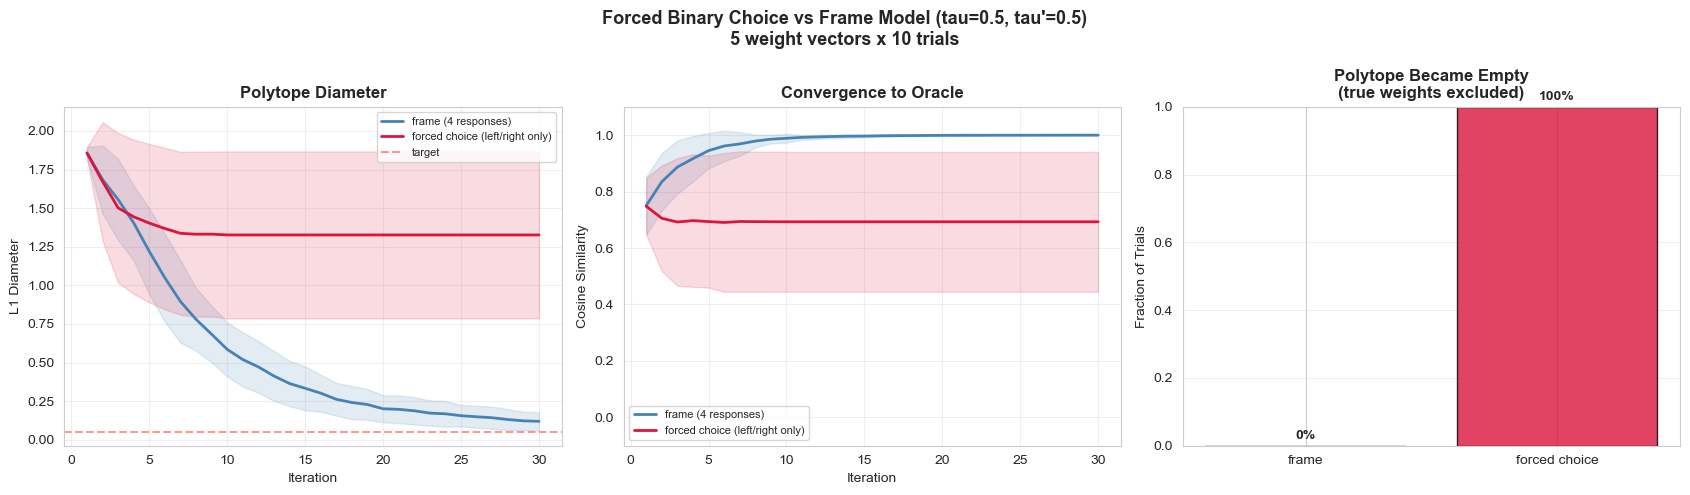

In [33]:
# Analyze: how often does forced-choice make the polytope empty?
# And compare convergence + final cosine similarity

colors_fc = {
    'frame (4 responses)': 'steelblue',
    'forced choice (left/right only)': 'crimson',
}

# Extract curves
fc_diameters = {m: [] for m in fc_models}
fc_cossims = {m: [] for m in fc_models}
fc_emptied = {m: 0 for m in fc_models}
fc_total = {m: 0 for m in fc_models}

for w_idx in results_fc:
    for m in fc_models:
        for hist in results_fc[w_idx][m]:
            fc_total[m] += 1
            diams = [h['diameter'] for h in hist]
            cossims = [h.get('cosine_similarity', np.nan) for h in hist]

            # Detect if polytope went empty (history shorter than max_iter
            # AND last diameter didn't reach target)
            if len(hist) < max_iter_fc and (not diams or diams[-1] > 0.05):
                fc_emptied[m] += 1

            while len(diams) < max_iter_fc:
                diams.append(diams[-1] if diams else np.nan)
            while len(cossims) < max_iter_fc:
                cossims.append(cossims[-1] if cossims else np.nan)

            fc_diameters[m].append(diams[:max_iter_fc])
            fc_cossims[m].append(cossims[:max_iter_fc])

for m in fc_models:
    fc_diameters[m] = np.array(fc_diameters[m])
    fc_cossims[m] = np.array(fc_cossims[m])

print('Polytope emptied (infeasible):')
for m in fc_models:
    print(f'  {m:35s}: {fc_emptied[m]}/{fc_total[m]} '
          f'({fc_emptied[m]/fc_total[m]*100:.0f}%)')

# Plot
iters_fc = np.arange(1, max_iter_fc + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Diameter
ax = axes[0]
for m in fc_models:
    mean = np.nanmean(fc_diameters[m], axis=0)
    std = np.nanstd(fc_diameters[m], axis=0)
    ax.plot(iters_fc, mean, '-', color=colors_fc[m], label=m, linewidth=2)
    ax.fill_between(iters_fc, mean - std, mean + std, color=colors_fc[m], alpha=0.15)
ax.axhline(0.05, color='red', linestyle='--', alpha=0.4, label='target')
ax.set_xlabel('Iteration'); ax.set_ylabel('L1 Diameter')
ax.set_title('Polytope Diameter', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Cosine similarity
ax = axes[1]
for m in fc_models:
    mean = np.nanmean(fc_cossims[m], axis=0)
    std = np.nanstd(fc_cossims[m], axis=0)
    ax.plot(iters_fc, mean, '-', color=colors_fc[m], label=m, linewidth=2)
    ax.fill_between(iters_fc, mean - std, mean + std, color=colors_fc[m], alpha=0.15)
ax.set_xlabel('Iteration'); ax.set_ylabel('Cosine Similarity')
ax.set_title('Convergence to Oracle', fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Emptied fraction bar chart
ax = axes[2]
names = list(fc_models.keys())
emptied_fracs = [fc_emptied[m] / fc_total[m] for m in names]
bars = ax.bar(range(len(names)), emptied_fracs,
              color=[colors_fc[m] for m in names], edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=10)
ax.set_ylabel('Fraction of Trials')
ax.set_title('Polytope Became Empty\n(true weights excluded)', fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, frac in zip(bars, emptied_fracs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{frac*100:.0f}%', ha='center', fontweight='bold')

fig.suptitle(f'Forced Binary Choice vs Frame Model (tau={EXP_TAU}, tau\'={EXP_TAU_PRIME})\n'
             f'{n_weights_fc} weight vectors x {n_trials_fc} trials',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Sample Complexity: Full vs Decisive-Only Query Selection

Compare convergence speed when the learner searches over **all candidate queries** vs only **decisive queries** (those likely to produce left/right).

In [35]:
# Sample complexity experiment: decisive_only=True vs decisive_only=False
import time

# np.random.seed(42)

# Explicit tau values — must be non-zero for decisive_only filter to matter!
EXP_TAU_SC = 0.5
EXP_TAU_PRIME_SC = 0.5

n_weights_sc = 5
n_trials_sc = 10
max_iter_sc = 30
target_diam_sc = 0.1
weight_vectors_sc = np.random.dirichlet(np.ones(5), size=n_weights_sc)

# Use frame oracle with explicit tau
frame_oracle_sc = make_frame_oracle(EXP_TAU_SC, EXP_TAU_PRIME_SC)

query_modes = {
    'decisive only': True,
    'all queries': False,
}

results_sc = {}
t0 = time.time()
total_sc = n_weights_sc * len(query_modes) * n_trials_sc
done_sc = 0

for w_idx, w_vec in enumerate(weight_vectors_sc):
    results_sc[w_idx] = {}
    for mode_name, decisive_flag in query_modes.items():
        trials = []
        for trial in range(n_trials_sc):
            np.random.seed(w_idx * 1000 + trial)
            _, hist = active_learning_polytope(
                max_iterations=max_iter_sc,
                n_samples=5000,
                n_candidates=100,
                geometry='simplex',
                tau=EXP_TAU_SC,
                tau_prime=EXP_TAU_PRIME_SC,
                oracle_weights=w_vec,
                oracle_model=frame_oracle_sc,
                decisive_only=decisive_flag,
                target_diameter=target_diam_sc,
                verbose=False,
            )
            trials.append(hist)
            done_sc += 1

        results_sc[w_idx][mode_name] = trials
        elapsed = time.time() - t0
        rate = done_sc / elapsed if elapsed > 0 else 0
        remaining = (total_sc - done_sc) / rate if rate > 0 else 0
        print(f'  w[{w_idx}] {mode_name:20s}: done  [{done_sc}/{total_sc}, ~{remaining:.0f}s left]')

print(f'\nDone in {time.time() - t0:.1f}s')
print(f'Using tau={EXP_TAU_SC}, tau_prime={EXP_TAU_PRIME_SC}')

  w[0] decisive only       : done  [10/100, ~3141s left]
  w[0] all queries         : done  [20/100, ~2585s left]
  w[1] decisive only       : done  [30/100, ~2323s left]
  w[1] all queries         : done  [40/100, ~1977s left]
  w[2] decisive only       : done  [50/100, ~1703s left]
  w[2] all queries         : done  [60/100, ~1974s left]
  w[3] decisive only       : done  [70/100, ~1509s left]
  w[3] all queries         : done  [80/100, ~1003s left]
  w[4] decisive only       : done  [90/100, ~494s left]
  w[4] all queries         : done  [100/100, ~0s left]

Done in 4826.0s
Using tau=0.5, tau_prime=0.5


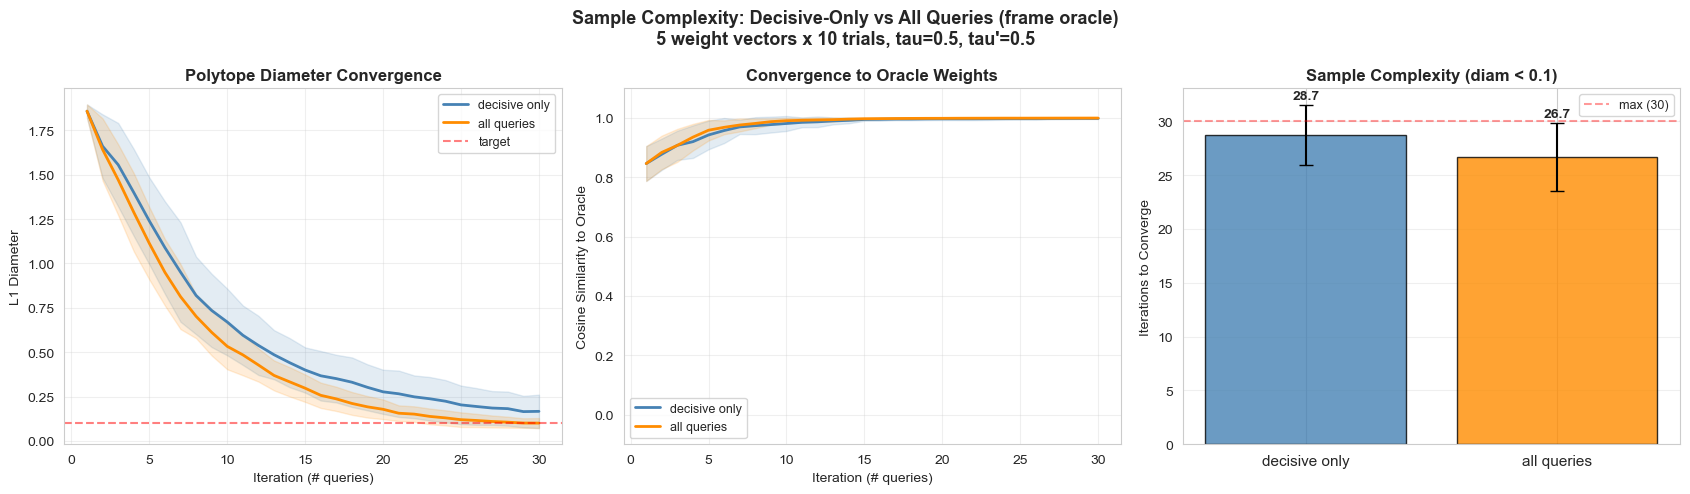

decisive only       : converged 28%, mean iters = 28.7 +/- 2.8
all queries         : converged 64%, mean iters = 26.7 +/- 3.2


In [36]:
# Aggregate and plot: decisive-only vs all queries
colors_sc = {'decisive only': 'steelblue', 'all queries': 'darkorange'}

# Extract diameter and cosine sim curves
sc_diameters = {m: [] for m in query_modes}
sc_cossims = {m: [] for m in query_modes}

for w_idx in results_sc:
    for mode_name in query_modes:
        for hist in results_sc[w_idx][mode_name]:
            diams = [h['diameter'] for h in hist]
            cossims = [h.get('cosine_similarity', np.nan) for h in hist]
            while len(diams) < max_iter_sc:
                diams.append(diams[-1] if diams else np.nan)
            while len(cossims) < max_iter_sc:
                cossims.append(cossims[-1] if cossims else np.nan)
            sc_diameters[mode_name].append(diams[:max_iter_sc])
            sc_cossims[mode_name].append(cossims[:max_iter_sc])

for m in query_modes:
    sc_diameters[m] = np.array(sc_diameters[m])
    sc_cossims[m] = np.array(sc_cossims[m])

iters_sc = np.arange(1, max_iter_sc + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Diameter convergence ---
ax = axes[0]
for m in query_modes:
    mean = np.nanmean(sc_diameters[m], axis=0)
    std = np.nanstd(sc_diameters[m], axis=0)
    ax.plot(iters_sc, mean, '-', color=colors_sc[m], label=m, linewidth=2)
    ax.fill_between(iters_sc, mean - std, mean + std, color=colors_sc[m], alpha=0.15)
ax.axhline(target_diam_sc, color='red', linestyle='--', alpha=0.5, label='target')
ax.set_xlabel('Iteration (# queries)')
ax.set_ylabel('L1 Diameter')
ax.set_title('Polytope Diameter Convergence', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Cosine similarity ---
ax = axes[1]
for m in query_modes:
    mean = np.nanmean(sc_cossims[m], axis=0)
    std = np.nanstd(sc_cossims[m], axis=0)
    ax.plot(iters_sc, mean, '-', color=colors_sc[m], label=m, linewidth=2)
    ax.fill_between(iters_sc, mean - std, mean + std, color=colors_sc[m], alpha=0.15)
ax.set_xlabel('Iteration (# queries)')
ax.set_ylabel('Cosine Similarity to Oracle')
ax.set_title('Convergence to Oracle Weights', fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Iterations to converge bar chart ---
ax = axes[2]
convergence_sc = {m: [] for m in query_modes}
for w_idx in results_sc:
    for m in query_modes:
        for hist in results_sc[w_idx][m]:
            diams = [h['diameter'] for h in hist]
            converged_at = max_iter_sc
            for i, d in enumerate(diams):
                if d <= target_diam_sc:
                    converged_at = i + 1
                    break
            convergence_sc[m].append(converged_at)

mode_names = list(query_modes.keys())
means_sc = [np.mean(convergence_sc[m]) for m in mode_names]
stds_sc = [np.std(convergence_sc[m]) for m in mode_names]

bars = ax.bar(range(len(mode_names)), means_sc, yerr=stds_sc, capsize=5,
              color=[colors_sc[m] for m in mode_names], edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, fontsize=11)
ax.set_ylabel('Iterations to Converge')
ax.set_title(f'Sample Complexity (diam < {target_diam_sc})', fontweight='bold')
ax.axhline(max_iter_sc, color='red', linestyle='--', alpha=0.4, label=f'max ({max_iter_sc})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for bar, mean, std in zip(bars, means_sc, stds_sc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.3,
            f'{mean:.1f}', ha='center', va='bottom', fontweight='bold')

fig.suptitle(f'Sample Complexity: Decisive-Only vs All Queries (frame oracle)\n'
             f'{n_weights_sc} weight vectors x {n_trials_sc} trials, tau={EXP_TAU_SC}, tau\'={EXP_TAU_PRIME_SC}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
for m in mode_names:
    frac = np.mean(np.array(convergence_sc[m]) < max_iter_sc)
    print(f'{m:20s}: converged {frac*100:.0f}%, '
          f'mean iters = {np.mean(convergence_sc[m]):.1f} +/- {np.std(convergence_sc[m]):.1f}')